In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
from torchvision import transforms
import pandas as pd

In [28]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers=1, dropout=0):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)

    def forward(self, src):

        embedded = self.embedding(src)

        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

In [29]:
class Decoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, n_layers=1, dropout=0):
        super().__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Linear(output_dim, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):

        input = input.unsqueeze(1)

        embedded = self.embedding(input)

        output, hidden = self.rnn(embedded, hidden)

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden


In [30]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]
        trg_seq_len = trg.shape[1]
        output_dim = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_seq_len, output_dim).to(self.device)
        _, hidden = self.encoder(src)

        input = trg[:, 0, :]

        for t in range(1, trg_seq_len):
            prediction, hidden = self.decoder(input, hidden)

            outputs[:, t, :] = prediction

            teacher_force = torch.rand(1).item() < teacher_forcing_ratio

            input = trg[:, t, :] if teacher_force else prediction

        return outputs


In [31]:
class SimpleAdditionDataset:
    def __init__(self, num_samples=1000, seq_len=5, input_dim=1, output_dim=1):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.input_seqs = np.random.rand(num_samples, seq_len, input_dim).astype(np.float32)
        self.target_seqs = np.zeros((num_samples, seq_len, output_dim), dtype=np.float32)

        for i in range(num_samples):
            self.target_seqs[i, :, 0] = np.cumsum(self.input_seqs[i, :, 0])

        self.input_seqs = torch.from_numpy(self.input_seqs)
        self.target_seqs = torch.from_numpy(self.target_seqs)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.input_seqs[idx], self.target_seqs[idx]


In [32]:
def visualize_sample(dataset, idx=0):
    input_seq, target_seq = dataset[idx]

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(input_seq[:, 0].numpy(), '-o', label='Input Sequence')
    plt.title('Input Sequence')
    plt.xlabel('Sequence Position')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(target_seq[:, 0].numpy(), '-o', label='Target Sequence')
    plt.title('Target Sequence (Cumulative Sum)')
    plt.xlabel('Sequence Position')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


In [33]:
def visualize_architecture():
    plt.figure(figsize=(15, 8))

    encoder_x = 1
    decoder_x = 4
    hidden_y = 2
    input_y = 4
    output_y = 0
    box_width = 1.5
    box_height = 3

    encoder = plt.Rectangle((encoder_x-box_width/2, hidden_y-box_height/2), box_width, box_height,
                         fc='lightblue', ec='blue', alpha=0.7)
    plt.gca().add_patch(encoder)
    plt.text(encoder_x, hidden_y, 'Encoder', ha='center', va='center', fontsize=14)

    decoder = plt.Rectangle((decoder_x-box_width/2, hidden_y-box_height/2), box_width, box_height,
                         fc='lightgreen', ec='green', alpha=0.7)
    plt.gca().add_patch(decoder)
    plt.text(decoder_x, hidden_y, 'Decoder', ha='center', va='center', fontsize=14)

    plt.arrow(encoder_x, input_y, 0, -1, head_width=0.1, head_length=0.2, fc='black', ec='black')
    plt.text(encoder_x, input_y+0.2, 'Input Sequence', ha='center', va='center', fontsize=12)

    plt.arrow(decoder_x, hidden_y+box_height/2, 0, 1, head_width=0.1, head_length=0.2, fc='black', ec='black')
    plt.text(decoder_x, input_y+0.2, 'Target Sequence (Input)', ha='center', va='center', fontsize=12)

    plt.arrow(decoder_x, hidden_y-box_height/2, 0, -1, head_width=0.1, head_length=0.2, fc='black', ec='black')
    plt.text(decoder_x, output_y-0.2, 'Output Sequence', ha='center', va='center', fontsize=12)

    plt.arrow(encoder_x+box_width/2, hidden_y, decoder_x-encoder_x-box_width, 0,
             head_width=0.1, head_length=0.2, fc='red', ec='red')
    plt.text((encoder_x+decoder_x)/2, hidden_y+0.3, 'Hidden State', ha='center', va='center', color='red', fontsize=12)

    plt.xlim(0, 6)
    plt.ylim(-1, 5)
    plt.axis('off')
    plt.title('Encoder-Decoder Architecture', fontsize=16)
    plt.tight_layout()
    plt.show()


In [34]:
def visualize_attention(attention_weights):
    """
    Visualize attention weights matrix
    attention_weights: numpy array of shape (output_seq_len, input_seq_len)
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_weights, annot=True, cmap='viridis')
    plt.xlabel('Input Sequence Position')
    plt.ylabel('Output Sequence Position')
    plt.title('Attention Weights')
    plt.tight_layout()
    plt.show()


In [35]:
def visualize_training_progress(losses):
    """
    Visualize training loss over epochs
    losses: list of loss values
    """
    plt.figure(figsize=(10, 6))
    plt.plot(losses, '-o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [36]:
# Visualize hidden state activations
def visualize_hidden_states(hidden_states):
    """
    Visualize hidden state activations over sequence length
    hidden_states: numpy array of shape (seq_len, hidden_dim)
    """
    plt.figure(figsize=(12, 8))
    sns.heatmap(hidden_states, cmap='coolwarm')
    plt.xlabel('Hidden Dimension')
    plt.ylabel('Sequence Position')
    plt.title('Hidden State Activations')
    plt.tight_layout()
    plt.show()


In [37]:
def train(model, dataset, epochs=20, batch_size=32, learning_rate=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for i, (src, trg) in enumerate(data_loader):
            src = src.to(device)
            trg = trg.to(device)

            optimizer.zero_grad()

            output = model(src, trg)

            loss = criterion(output[:, 1:, :], trg[:, 1:, :])

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(data_loader)
        losses.append(avg_epoch_loss)

        print(f'Epoch: {epoch+1}, Loss: {avg_epoch_loss:.6f}')

    visualize_training_progress(losses)
    return model, losses



In [38]:
def get_hidden_states(model, input_seq):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    input_seq = input_seq.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(input_seq)

    return encoder_outputs.squeeze(0).cpu().numpy(), hidden.squeeze(0).cpu().numpy()


In [39]:
def predict_and_visualize(model, input_seq, target_seq=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    input_seq = input_seq.unsqueeze(0).to(device)
    if target_seq is not None:
        target_seq = target_seq.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(input_seq)

        if target_seq is not None:
            decoder_input = target_seq[:, 0, :]
        else:
            decoder_input = torch.zeros(1, model.decoder.output_dim).to(device)

        seq_len = input_seq.shape[1]
        outputs = torch.zeros(1, seq_len, model.decoder.output_dim).to(device)

        all_hidden_states = []
        all_hidden_states.append(hidden[-1].cpu().numpy())

        for t in range(1, seq_len):
            prediction, hidden = model.decoder(decoder_input, hidden)

            outputs[:, t, :] = prediction

            decoder_input = prediction

            all_hidden_states.append(hidden[-1].cpu().numpy())

    input_np = input_seq.squeeze(0).cpu().numpy()
    output_np = outputs.squeeze(0).cpu().numpy()
    target_np = target_seq.squeeze(0).cpu().numpy() if target_seq is not None else None
    hidden_states_np = np.array(all_hidden_states)

    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(input_np[:, 0], '-o', label='Input')
    plt.title('Input Sequence')
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(output_np[:, 0], '-o', label='Predicted')
    if target_np is not None:
        plt.plot(target_np[:, 0], '-o', label='Target')
    plt.title('Output vs Target Sequence')
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    hidden_states_np = hidden_states_np.reshape(hidden_states_np.shape[0], -1)
    sns.heatmap(hidden_states_np, cmap='viridis')
    plt.title('Hidden States Over Time')
    plt.xlabel('Hidden Dimension')
    plt.ylabel('Time Step')

    plt.tight_layout()
    plt.show()

    return output_np





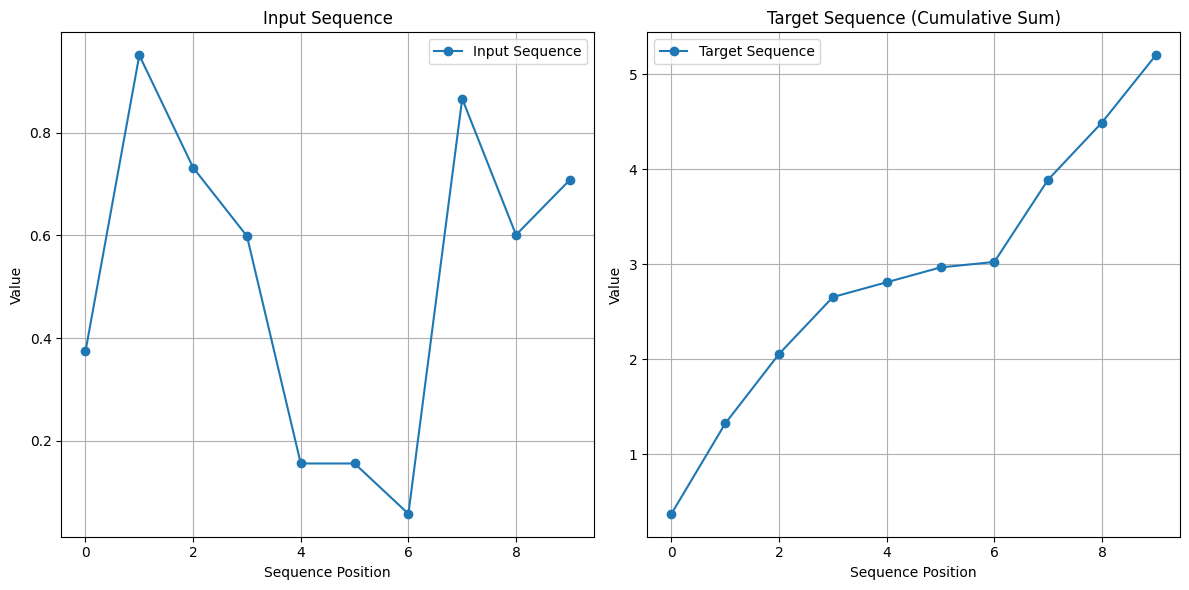

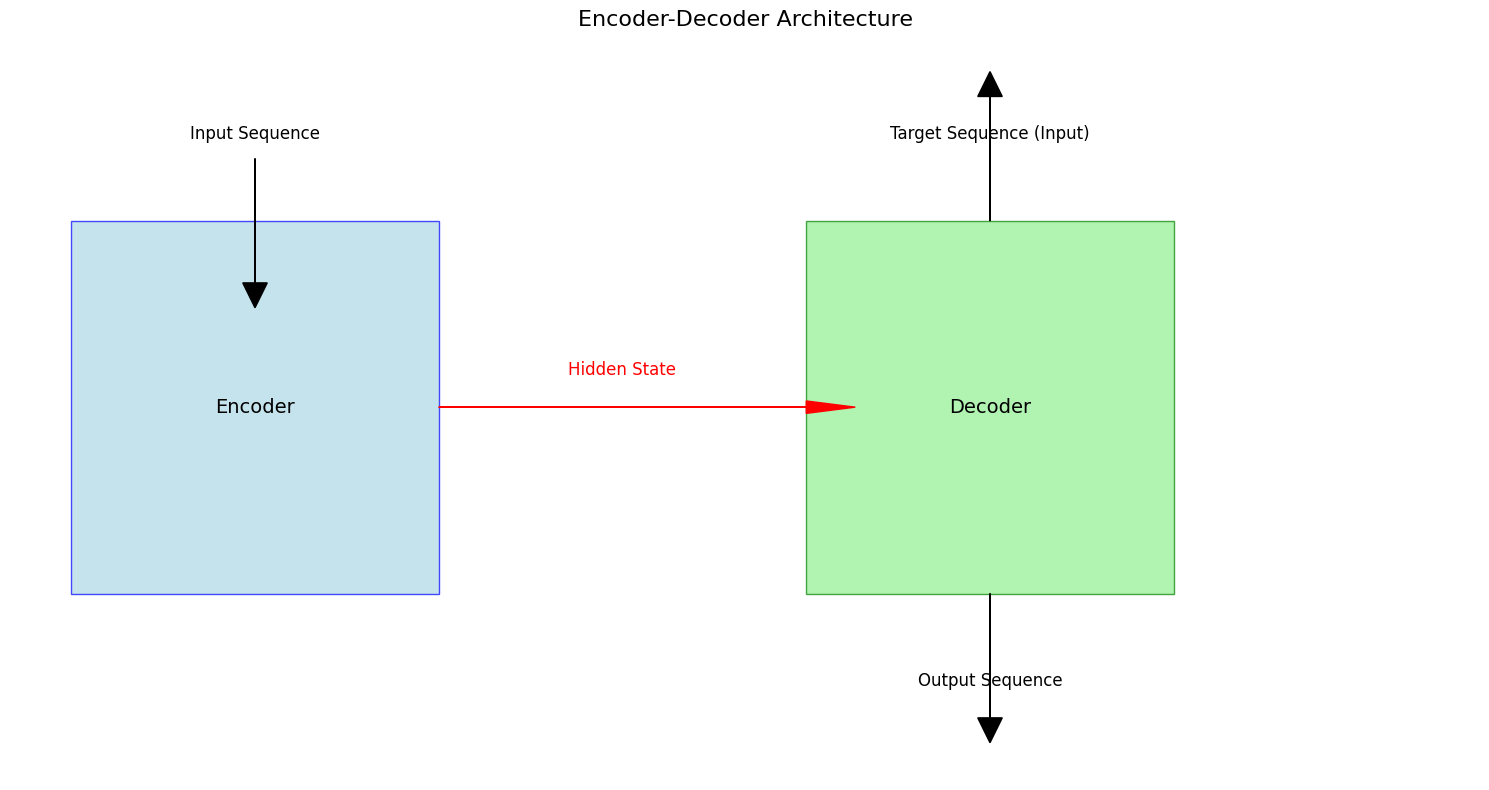

EncoderDecoder(
  (encoder): Encoder(
    (embedding): Linear(in_features=1, out_features=64, bias=True)
    (rnn): GRU(64, 64, num_layers=2, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Linear(in_features=1, out_features=64, bias=True)
    (rnn): GRU(64, 64, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 100161
Epoch: 1, Loss: 3.019039
Epoch: 2, Loss: 0.519745
Epoch: 3, Loss: 0.326964
Epoch: 4, Loss: 0.221317
Epoch: 5, Loss: 0.128093
Epoch: 6, Loss: 0.089883
Epoch: 7, Loss: 0.075422
Epoch: 8, Loss: 0.065191
Epoch: 9, Loss: 0.057631
Epoch: 10, Loss: 0.052489
Epoch: 11, Loss: 0.049883
Epoch: 12, Loss: 0.047299
Epoch: 13, Loss: 0.045256
Epoch: 14, Loss: 0.042558
Epoch: 15, Loss: 0.042393
Epoch: 16, Loss: 0.038447
Epoch: 17, Loss: 0.036077
Epoch: 18, Loss: 0.035188
Epoch: 19, Loss: 0.036317
Epoch: 20, Loss: 0.033115
Epoch: 21, Loss: 0.033690
Epoch: 22, Loss: 0.032067
Epoch: 23, Loss: 0.030102
Epoch: 

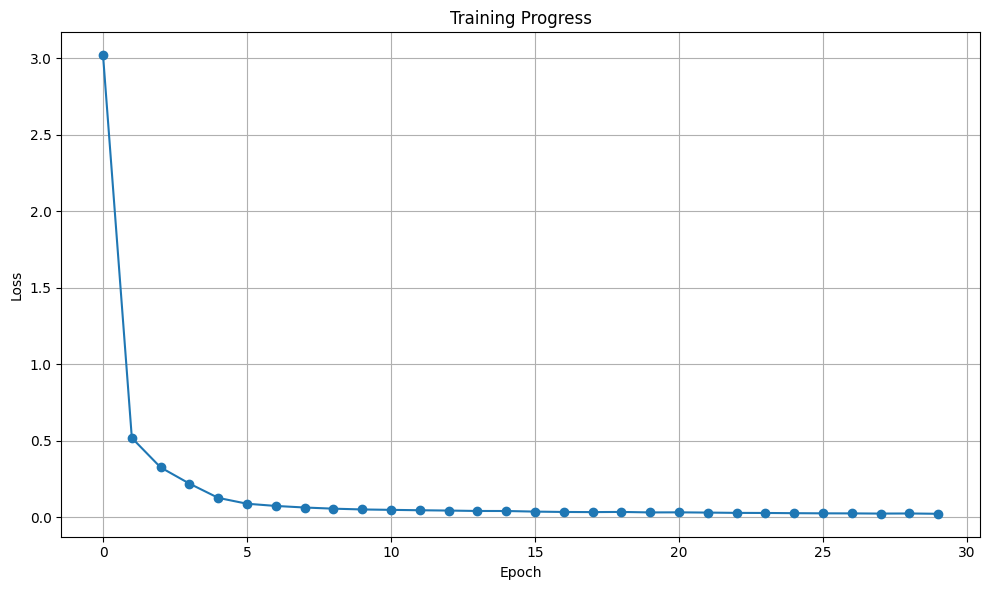

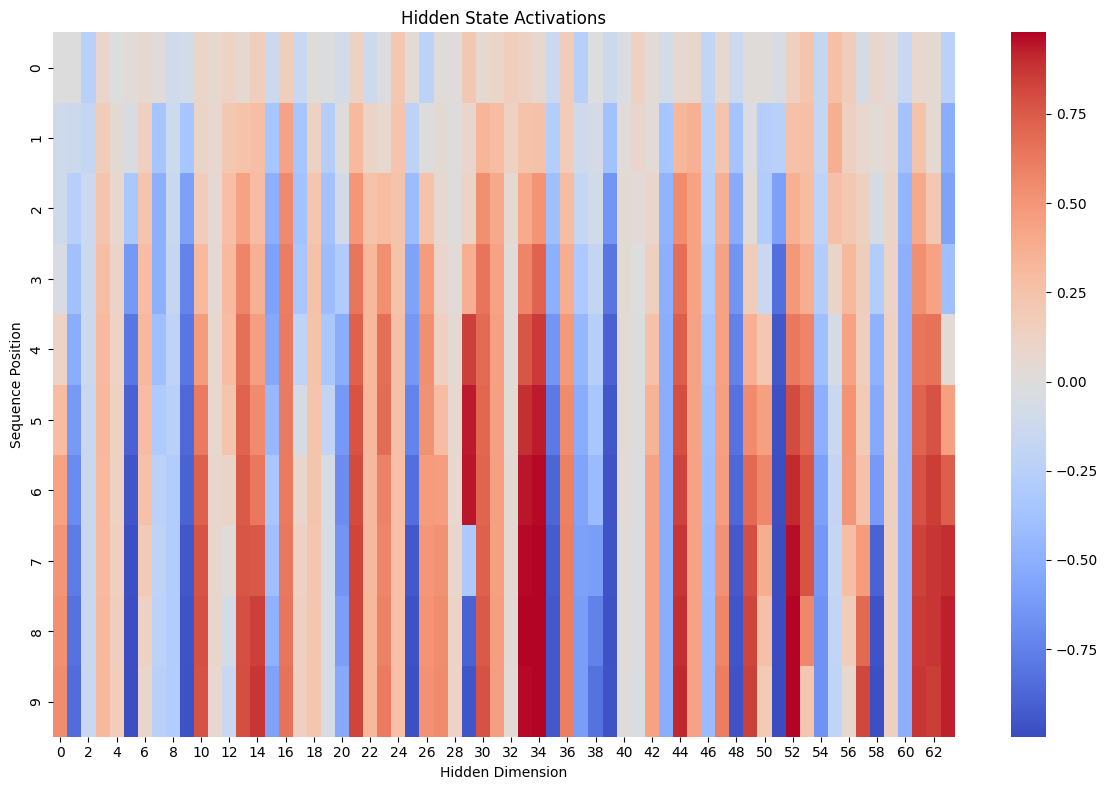

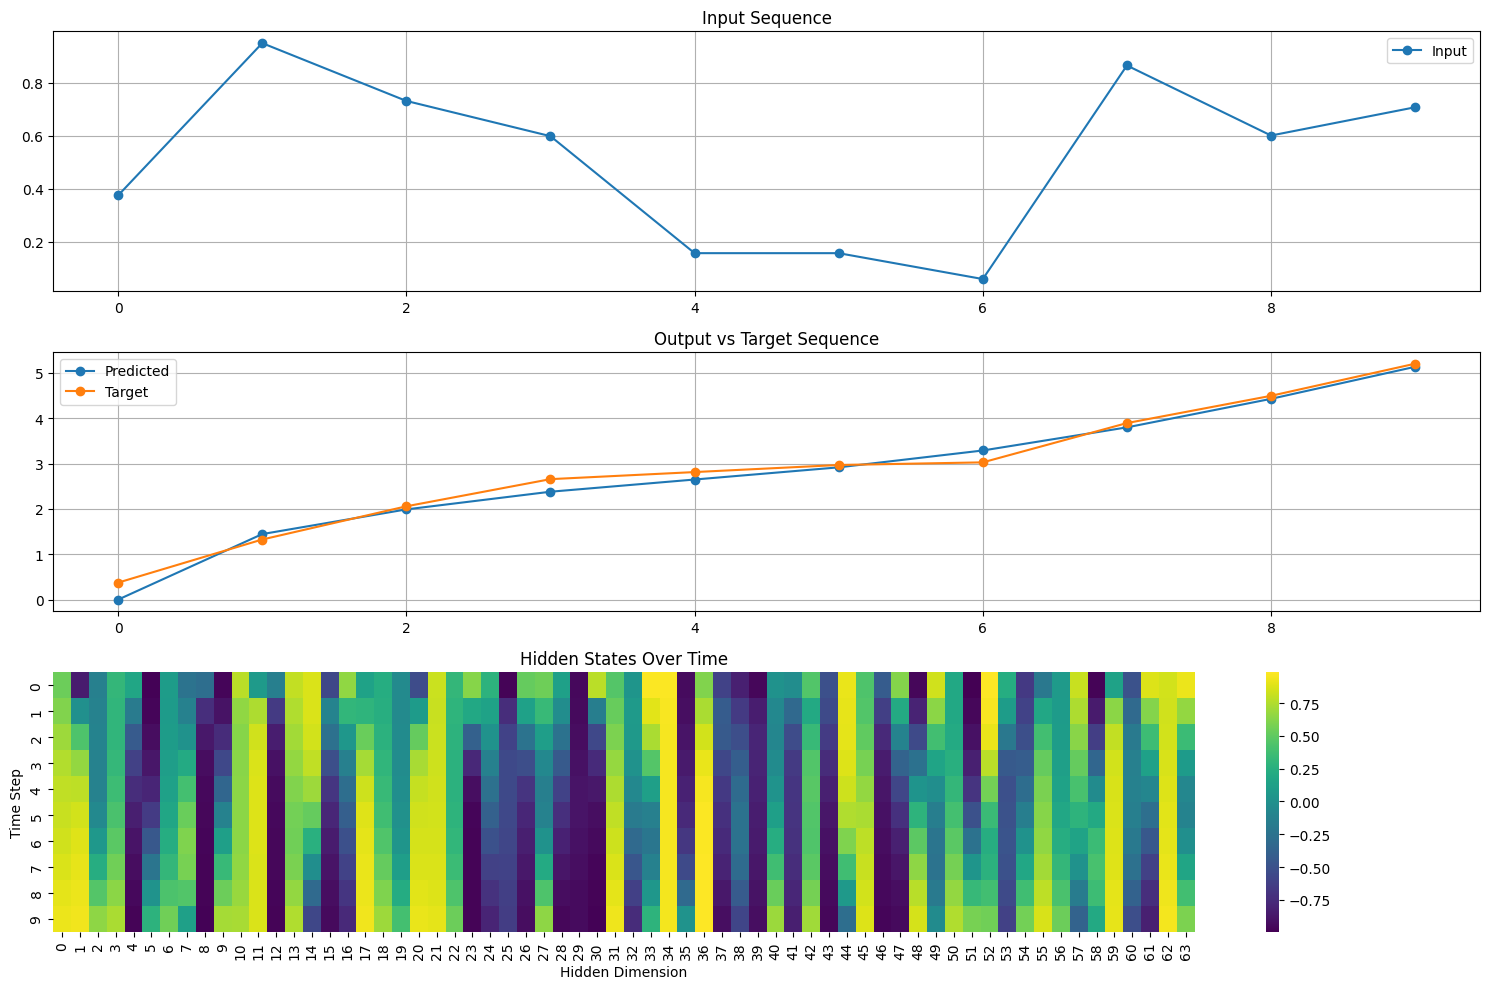

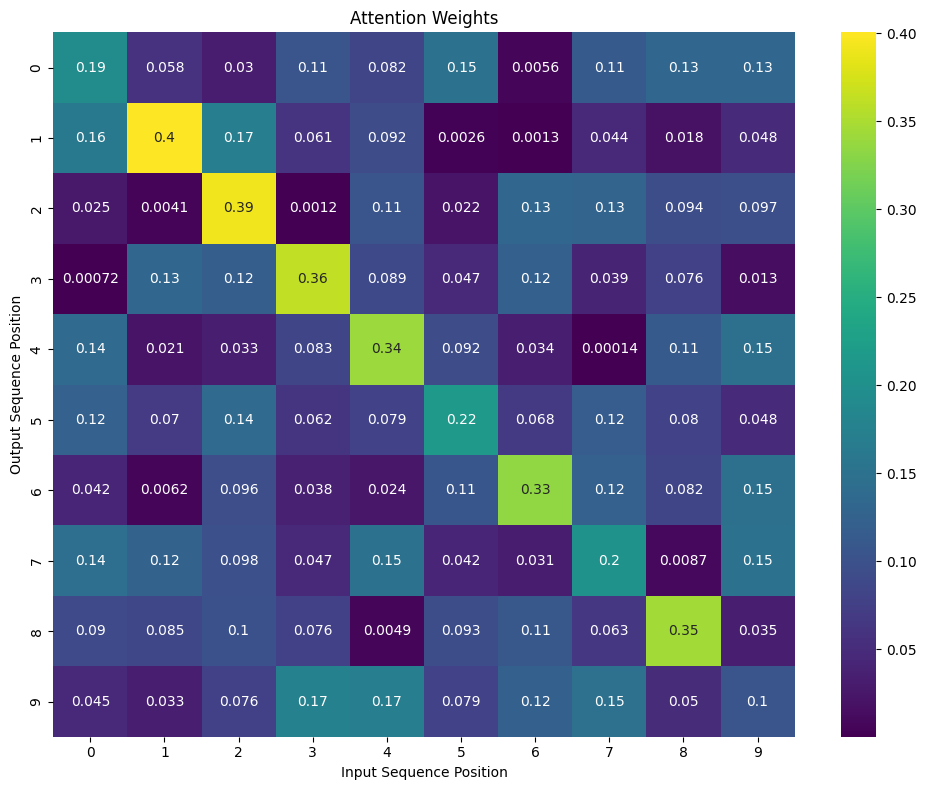

In [14]:
def main():
    torch.manual_seed(42)
    np.random.seed(42)

    input_dim = 1
    output_dim = 1
    hidden_dim = 64
    n_layers = 2
    seq_len = 10
    batch_size = 32
    epochs = 30

    dataset = SimpleAdditionDataset(
        num_samples=1000,
        seq_len=seq_len,
        input_dim=input_dim,
        output_dim=output_dim
    )

    visualize_sample(dataset)

    visualize_architecture()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    encoder = Encoder(input_dim, hidden_dim, n_layers)
    decoder = Decoder(output_dim, hidden_dim, n_layers)

    model = EncoderDecoder(encoder, decoder, device)

    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

    model, losses = train(model, dataset, epochs=epochs, batch_size=batch_size)

    test_input, test_target = dataset[0]

    encoder_outputs, hidden = get_hidden_states(model, test_input)
    visualize_hidden_states(encoder_outputs)

    predict_and_visualize(model, test_input, test_target)

    mock_attention = np.random.rand(seq_len, seq_len)
    for i in range(seq_len):
        for j in range(seq_len):
            if i == j:
                mock_attention[i, j] *= 3
    mock_attention = mock_attention / mock_attention.sum(axis=1, keepdims=True)
    visualize_attention(mock_attention)

if __name__ == "__main__":
    main()